In [3]:
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype
import json
import matplotlib.pyplot as plt
import seaborn as sns
import regex as re

In [13]:
# Load some data
with open("data/league-fixture/big_fixture_data.json") as file:
    data = json.loads(file.read())

JSONDecodeError: Expecting ',' delimiter: line 107353 column 26 (char 3402043)

In [5]:
last_season_data = data["2023-2024"]
df = pd.DataFrame()
for k, v in last_season_data.items():
    v = pd.DataFrame.from_dict(v)
    v["league"] = k
    df = pd.concat([df, v])

df.reset_index(drop=True, inplace=True)
df.head()

NameError: name 'data' is not defined

In [4]:
df.groupby("league").size()

league
Bundesliga        306
La-Liga           380
Ligue-1           306
Premier-League    380
Serie-A           380
dtype: int64

In [5]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 53 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Wk                1748 non-null   float64
 1   Day               1748 non-null   object 
 2   Date              1748 non-null   object 
 3   Time              1748 non-null   object 
 4   Home              1748 non-null   object 
 5   Away              1748 non-null   object 
 6   xG                1748 non-null   float64
 7   xG.1              1748 non-null   float64
 8   Score             1748 non-null   object 
 9   Attendance        1748 non-null   float64
 10  Referee           1748 non-null   object 
 11  season            1748 non-null   object 
 12  t1_captain        1751 non-null   object 
 13  t2_captain        1751 non-null   object 
 14  t1_formation      1751 non-null   object 
 15  t2_formation      1751 non-null   object 
 16  t1_possession     1751 non-null   object 


In [6]:
# I want to look into the leagues that have the least amount of goals scored
# I will add a column of the total goals scored in a game
df.dropna(subset=["Score"], inplace=True)
df["home_goals"] = df["Score"].str[0]
df["away_goals"] = df["Score"].str[-1]
df = df.astype({"home_goals": "int32", "away_goals": "int32"})
df.dtypes

Wk                  float64
Day                  object
Date                 object
Time                 object
Home                 object
Away                 object
xG                  float64
xG.1                float64
Score                object
Attendance          float64
Referee              object
season               object
t1_captain           object
t2_captain           object
t1_formation         object
t2_formation         object
t1_possession        object
t2_possession        object
t1_passing           object
t2_passing           object
t1_shots             object
t2_shots             object
t1_saves             object
t2_saves             object
t1_yellow_cards     float64
t1_red_cards        float64
t2_yellow_cards     float64
t2_red_cards        float64
t1_fouls            float64
t2_fouls            float64
t1_corners          float64
t2_corners          float64
t1_crosses          float64
t2_crosses          float64
t1_touches          float64
t2_touches          

In [7]:
# Find out the total number of goals per game.
df.groupby("league")[["home_goals", "away_goals"]].sum().sum(axis=1) / df.groupby("league").size()

league
Bundesliga        3.218954
La-Liga           2.644737
Ligue-1           2.697368
Premier-League    3.278947
Serie-A           2.597884
dtype: float64

In [8]:
# Gather the workflow into a function to be able to do this for every season of interest.
def goals_per_game(season):
    season_data = data[season]
    df = pd.DataFrame()
    for k, v in season_data.items():
        v = pd.DataFrame.from_dict(v)
        v["league"] = k
        df = pd.concat([df, v])

    df.reset_index(drop=True, inplace=True)
    df.dropna(subset=["Score"], inplace=True)
    df["home_goals"] = df["Score"].str[0]
    df["away_goals"] = df["Score"].str[-1]
    df = df.astype({"home_goals": "int32", "away_goals": "int32"})
    table = df.groupby("league")[["home_goals", "away_goals"]].sum().sum(axis=1) / df.groupby("league").size()
    table = table.to_frame()
    table.columns = [season]

    return(table)

In [9]:
seasons = ["2017-2018", "2018-2019", "2019-2020", "2020-2021", "2021-2022", "2022-2023", "2023-2024", "2024-2025"]
leagues = [
        {"id": "9", "name": "Premier-League"}, {"id": "12", "name": "La-Liga"},
        {"id": "11", "name": "Serie-A"}, {"id": "13", "name": "Ligue-1"}, {"id": "20", "name": "Bundesliga"}
    ]
leagues = [l["name"] for l in leagues]
# Make sure the number of games is around 380
for season in seasons:
    for league in leagues:
        df = pd.DataFrame.from_dict(data[season][league])
        if len(df) < 370:
            print(season, league)
            print(len(df))


2017-2018 Bundesliga
306
2018-2019 Bundesliga
306
2019-2020 Bundesliga
308
2020-2021 Bundesliga
308
2021-2022 Bundesliga
308
2022-2023 Bundesliga
308
2023-2024 Ligue-1
306
2023-2024 Bundesliga
306
2024-2025 Premier-League
286
2024-2025 La-Liga
271
2024-2025 Ligue-1
306
2024-2025 Bundesliga
223


In [10]:
# Return the average number of goals scored per game for the past 8 seasons
gpg_df = pd.DataFrame()
for season in range(len(seasons)):
    gpg_df = pd.concat([gpg_df, goals_per_game(seasons[season])], axis=1)

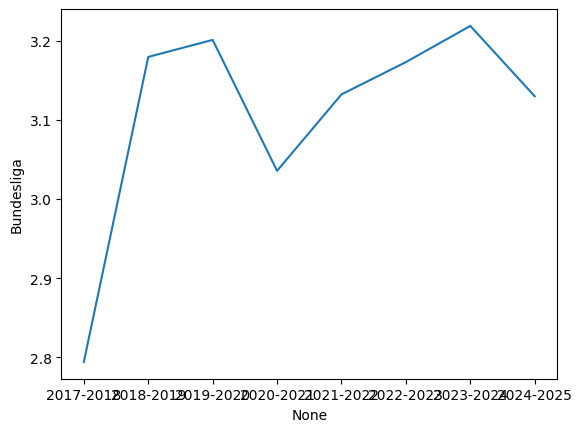

In [11]:
sns.lineplot(x=gpg_df.columns, y = gpg_df.iloc[0, :]) # Bundesliga goals per game
plt.show()

In [12]:
gpg_df

,2017-2018,2018-2019,2019-2020,2020-2021,2021-2022,2022-2023,2023-2024,2024-2025
league,,,,,,,,
Bundesliga,2.794118,3.179739,3.201299,3.035714,3.132404,3.173203,3.218954,3.130045
La-Liga,2.693931,2.586842,2.478947,2.507895,2.502632,2.513158,2.644737,2.645756
Ligue-1,2.722955,2.562005,2.523297,2.756545,2.817935,2.807895,2.697368,2.960714
Premier-League,2.678947,2.821053,2.722222,2.694737,2.818421,2.852243,3.278947,2.986014
Serie-A,2.676316,2.688654,3.036842,3.060526,2.849206,2.563158,2.597884,2.700000


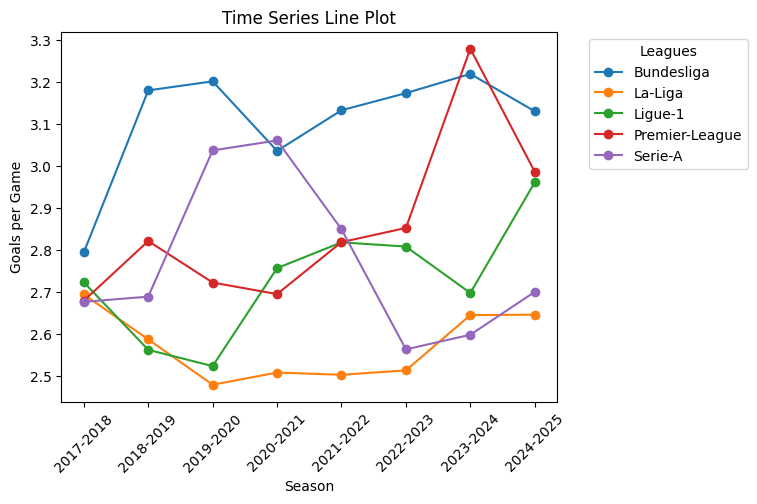

In [13]:
gpg_df.T.plot(marker="o")
plt.title('Time Series Line Plot')
plt.xlabel('Season')
plt.xticks(rotation=45)
plt.ylabel('Goals per Game')
plt.legend(title='Leagues', bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.show()

           league     season  goals_per_game
0      Bundesliga  2017-2018        2.794118
1         La-Liga  2017-2018        2.693931
2         Ligue-1  2017-2018        2.722955
3  Premier-League  2017-2018        2.678947
4         Serie-A  2017-2018        2.676316
5      Bundesliga  2018-2019        3.179739
6         La-Liga  2018-2019        2.586842


<Axes: xlabel='season', ylabel='goals_per_game'>

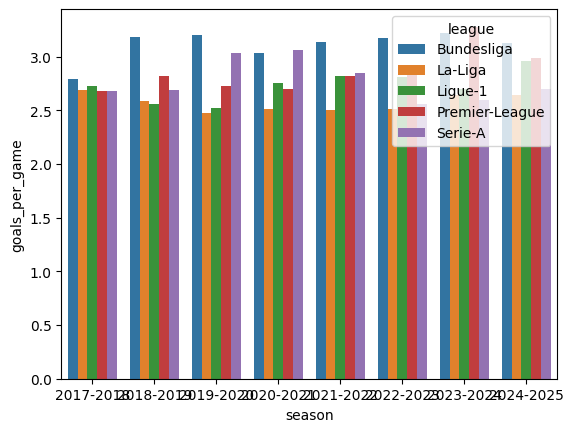

In [14]:
# Cluster bar chart
# I have to restructure the table to work with seaborn.
df = pd.melt(gpg_df.reset_index(),
            id_vars=[gpg_df.index.name], var_name="season", value_name="goals_per_game")
print(df.head(7))
sns.barplot(data=df, x="season", y="goals_per_game", hue="league")

In [15]:
# Perform EDA on Spanish League specifically
# What makes them least scoring league.

In [16]:
# Load some data
with open("data/league-fixture/big_fixture_data.json") as file:
    data = json.load(file)

In [17]:
# Gather all La-Liga data for the last 6 seasons
laliga_df = pd.DataFrame()
for season in list(data.keys())[2:]:
    v = pd.DataFrame.from_dict(data[season]["La-Liga"])
    v["league"] = "La-Liga"
    laliga_df = pd.concat([laliga_df, v])

laliga_df.reset_index(drop=True, inplace=True)
print(laliga_df.shape)
laliga_df.head()

(2171, 53)


,Wk,Day,Date,Time,Home,Away,xG,xG.1,Score,Attendance,...,t2_clearances,t1_offsides,t2_offsides,t1_goal_kicks,t2_goal_kicks,t1_throw_ins,t2_throw_ins,t1_long_balls,t2_long_balls,league
0,1.0,Fri,2019-08-16,21:00,Athletic Club,Barcelona,0.5,0.9,1–0,47693.0,...,12.0,2.0,1.0,15.0,10.0,16.0,17.0,61.0,63.0,La-Liga
1,1.0,Sat,2019-08-17,17:00,Celta Vigo,Real Madrid,1.6,2.1,1–3,23566.0,...,20.0,5.0,1.0,9.0,5.0,16.0,19.0,48.0,76.0,La-Liga
2,1.0,Sat,2019-08-17,19:00,Valencia,Real Sociedad,2.3,1.8,1–1,41846.0,...,11.0,2.0,2.0,9.0,6.0,13.0,22.0,68.0,54.0,La-Liga
3,1.0,Sat,2019-08-17,20:00,Mallorca,Eibar,1.6,0.7,2–1,15127.0,...,19.0,3.0,0.0,10.0,11.0,25.0,24.0,80.0,88.0,La-Liga
4,1.0,Sat,2019-08-17,21:00,Villarreal,Granada,1.9,1.9,4–4,14753.0,...,5.0,3.0,6.0,11.0,7.0,18.0,12.0,75.0,73.0,La-Liga


In [18]:
# Gather non La-Liga data to compare statistics.
rest_df = pd.DataFrame()
for season in list(data.keys())[2:]:
    for league in data[season]:
        if league != "La-Liga":
            v = pd.DataFrame.from_dict(data[season][league])
            v["league"] = league
            rest_df = pd.concat([rest_df, v])
        else:
            pass

rest_df.drop("game_id", inplace=True, axis=1)
rest_df.reset_index(drop=True, inplace=True)
print(rest_df.shape)
rest_df.head()       

(8364, 53)


,Wk,Day,Date,Time,Home,Away,xG,xG.1,Score,Attendance,...,t2_clearances,t1_offsides,t2_offsides,t1_goal_kicks,t2_goal_kicks,t1_throw_ins,t2_throw_ins,t1_long_balls,t2_long_balls,league
0,1.0,Fri,2019-08-09,20:00,Liverpool,Norwich City,1.8,0.9,4–1,53333.0,...,40.0,0.0,5.0,6.0,15.0,18.0,28.0,66.0,56.0,Premier-League
1,1.0,Sat,2019-08-10,12:30,West Ham,Manchester City,1.1,3.2,0–5,59870.0,...,13.0,2.0,4.0,6.0,5.0,22.0,14.0,55.0,49.0,Premier-League
2,1.0,Sat,2019-08-10,15:00,Bournemouth,Sheffield Utd,1.3,1.3,1–1,10714.0,...,16.0,1.0,1.0,9.0,8.0,27.0,27.0,77.0,94.0,Premier-League
3,1.0,Sat,2019-08-10,15:00,Watford,Brighton,0.7,0.8,0–3,20245.0,...,25.0,0.0,3.0,7.0,8.0,26.0,19.0,60.0,84.0,Premier-League
4,1.0,Sat,2019-08-10,15:00,Crystal Palace,Everton,0.9,1.1,0–0,25151.0,...,19.0,4.0,0.0,10.0,5.0,30.0,39.0,69.0,79.0,Premier-League


In [19]:
# We have both dataframes. Now, we can proceed with our analysis.
print(laliga_df["t1_formation"].value_counts(normalize=True)[:5])
print(rest_df["t1_formation"].value_counts(normalize=True)[:5])

(4-4-2)      0.298052
(4-2-3-1)    0.220116
(4-3-3)      0.185361
(4-1-4-1)    0.062138
(5-3-2)      0.053712
Name: t1_formation, dtype: float64
(4-2-3-1)    0.258905
(4-3-3)      0.161341
(3-4-3)      0.154793
(3-5-2)      0.104505
(4-4-2)      0.093243
Name: t1_formation, dtype: float64


In [20]:
# I will be comparing a lot of columns so let's create a function for it
def compare_columns(df1, df2, column, normalize=True):

    try:
        df1_name = list(df1.keys())[0]
        df1 = list(df1.values())[0]

        df2_name = list(df2.keys())[0]
        df2 = list(df2.values())[0]
        
        if df1[column].dtype == "O":
            print(df1[column].value_counts(normalize=normalize)[:5])
            print("\n\n")
            print(df2[column].value_counts(normalize=normalize)[:5])
    
            # Generate two differenct plots, axes, whatever they're called.
            # plt.show()
    
        elif is_numeric_dtype(df1[column]) == True:
            print(df1[column].describe())
            print("\n\n")
            print(df2[column].describe())
    
            n_df1 = len(df1)
            n_df2 = len(df2)
            sns.kdeplot(data=df1, x = column, fill=True, alpha=0.5, linewidth=2, label=df1_name)
            sns.kdeplot(data=df2.set_index(pd.Index(range(n_df1, (n_df1 + n_df2)))), x = column, fill=True,
                         alpha=0.5, linewidth=2, color="pink", label=df2_name)
            plt.legend()
            plt.show()

    except TypeError:
        raise TypeError("Input 'df1' and 'df2' must be a dict with name and data pair.")
       

count    2171.000000
mean        1.097513
std         0.705334
min         0.000000
25%         0.600000
50%         0.900000
75%         1.500000
max         5.000000
Name: xG.1, dtype: float64



count    7932.000000
mean        1.269932
std         0.762825
min         0.000000
25%         0.700000
50%         1.100000
75%         1.700000
max         5.600000
Name: xG.1, dtype: float64


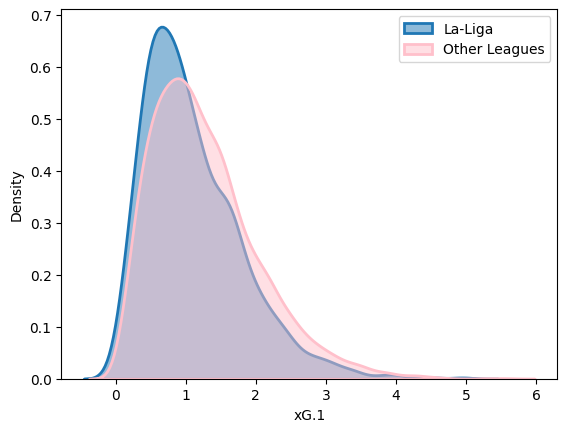

count    2171.000000
mean        1.429940
std         0.805927
min         0.100000
25%         0.800000
50%         1.300000
75%         1.900000
max         5.900000
Name: xG, dtype: float64



count    7932.000000
mean        1.513364
std         0.839947
min         0.000000
25%         0.900000
50%         1.400000
75%         2.000000
max         7.000000
Name: xG, dtype: float64


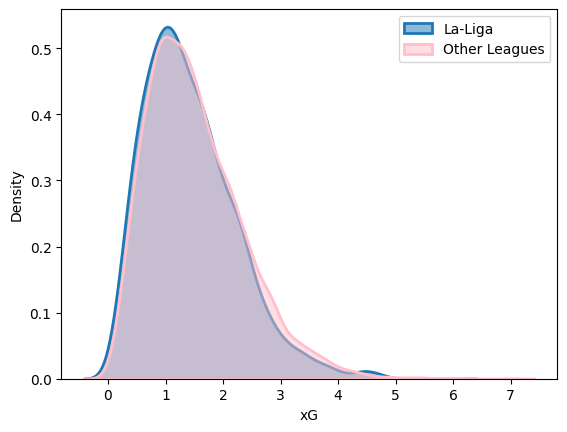

In [21]:
laliga_df["total_xG"] = laliga_df["xG"] + laliga_df["xG.1"]
rest_df["total_xG"] = rest_df["xG"] + rest_df["xG.1"]

compare_columns({"La-Liga": laliga_df}, {"Other Leagues": rest_df}, column = "xG.1")
compare_columns({"La-Liga": laliga_df}, {"Other Leagues": rest_df}, column = "xG") # The difference in home and away team xG seems significant

In [22]:
# Check the difference in possession between home and away teams
laliga_df["t1_possession"] = laliga_df["t1_possession"].str[0:2].astype("float")
laliga_df["t2_possession"] = laliga_df["t2_possession"].str[0:2].astype("float")
laliga_df["possession_diff"] = laliga_df["t1_possession"] - laliga_df["t2_possession"] # Can use a more simple formula
laliga_df["abs_possession_diff"] = abs(laliga_df["possession_diff"])

rest_df["t1_possession"] = rest_df["t1_possession"].str[0:2].astype("float")
rest_df["t2_possession"] = rest_df["t2_possession"].str[0:2].astype("float")
rest_df["possession_diff"] = rest_df["t1_possession"] - rest_df["t2_possession"]
rest_df["abs_possession_diff"] = abs(rest_df["possession_diff"])

count    1899.000000
mean        2.888889
std        22.696462
min       -64.000000
25%       -14.000000
50%         4.000000
75%        20.000000
max        64.000000
Name: possession_diff, dtype: float64



count    7636.000000
mean        2.017941
std        22.401067
min       -64.000000
25%       -14.000000
50%         2.000000
75%        18.000000
max        68.000000
Name: possession_diff, dtype: float64


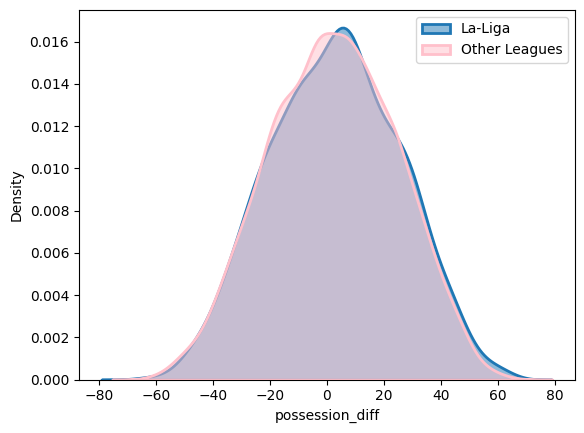

In [23]:
compare_columns({"La-Liga": laliga_df}, {"Other Leagues": rest_df}, "possession_diff") # There seems to be a home turf adv

count    1899.000000
mean       18.703528
std        13.170922
min         0.000000
25%         8.000000
50%        16.000000
75%        28.000000
max        64.000000
Name: abs_possession_diff, dtype: float64



count    7636.000000
mean       18.376244
std        12.967260
min         0.000000
25%         8.000000
50%        16.000000
75%        26.000000
max        68.000000
Name: abs_possession_diff, dtype: float64


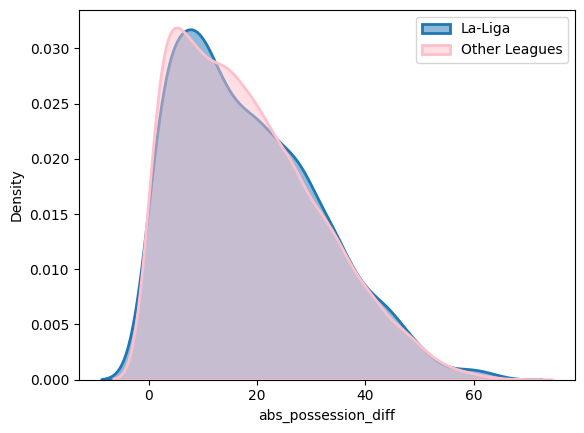

In [24]:
compare_columns({"La-Liga": laliga_df}, {"Other Leagues": rest_df}, "abs_possession_diff")

In [25]:
pattern1 = r"(\d+)\s+of\s+(\d+)\s+—\s+(\d+)%"
# pattern2 = r"\s+(\d+)%-(\d+)\s+of\s+(\d+)\s+"
pattern2 = r"(\d+)%\s*[—\-]\s*(\d+)\s+of\s+(\d+)"


# def parse_shot_data(data_string):
#     pattern = r"(\d+)\s+of\s+(\d+)\s+—\s+(\d+)%"
#     match = re.search(pattern, data_string)

#     if match:
#         return {
#             "successful_shots": int(match.group(1)),
#             "total_shots": int(match.group(2)),
#             "percentage": int(match.group(3))
#         }
#     else:
#         return None
        
def divide_shots_column_1(df, column):
    on_target = []
    shots_taken = []
    percentage_on_target = []
    for shot_str in df[column].dropna():
        # match = parse_shot_data(shot_str)
        match = re.search(pattern1, shot_str)

        if match:
            on_target.append(match[1])
            shots_taken.append(match.group(2))
            percentage_on_target.append(match[3])
    shot_data = pd.DataFrame({f"{column}_on_target": [int(e) for e in on_target], f"{column}_taken": [int(e) for e in shots_taken],
                              f"{column}_on_target_percentage": [int(e) for e in percentage_on_target]})
    
    return shot_data

def divide_shots_column_2(df, column):
    on_target = []
    shots_taken = []
    percentage_on_target = []
    for shot_str in df[column].dropna():
        # match = parse_shot_data(shot_str)
        match = re.search(pattern2, shot_str)

        if match:
            on_target.append(match[2])
            shots_taken.append(match.group(3))
            percentage_on_target.append(match[1])
    shot_data = pd.DataFrame({f"{column}_on_target": list(map(int, on_target)), f"{column}_taken": list(map(int, shots_taken)),
                              f"{column}_on_target_percentage": list(map(int,percentage_on_target))})
    
    return shot_data

In [26]:
# Divide t1_shots into percentage, total, and on target columns.
laliga_df = pd.concat([laliga_df, divide_shots_column_1(laliga_df, "t1_shots")], axis = 1)
laliga_df = pd.concat([laliga_df, divide_shots_column_2(laliga_df, "t2_shots")], axis = 1)

rest_df = pd.concat([rest_df, divide_shots_column_1(rest_df, "t1_shots")], axis = 1)
rest_df = pd.concat([rest_df, divide_shots_column_2(rest_df, "t2_shots")], axis = 1)

In [27]:
temp1 = laliga_df.copy()
temp1[["t1_shots_on_target", "t1_shots_taken", "t1_shots_on_target_percentage"]] = temp1[["t1_shots_on_target", "t1_shots_taken", "t1_shots_on_target_percentage"]].astype("Int64")
temp1[["t2_shots_on_target", "t2_shots_taken", "t2_shots_on_target_percentage"]] = temp1[["t2_shots_on_target", "t2_shots_taken", "t2_shots_on_target_percentage"]].astype("Int64")

temp2 = rest_df.copy()
temp2[["t1_shots_on_target", "t1_shots_taken", "t1_shots_on_target_percentage"]] = temp2[["t1_shots_on_target", "t1_shots_taken", "t1_shots_on_target_percentage"]].astype("Int64")
temp2[["t2_shots_on_target", "t2_shots_taken", "t2_shots_on_target_percentage"]] = temp2[["t2_shots_on_target", "t2_shots_taken", "t2_shots_on_target_percentage"]].astype("Int64")



count      1897.0
mean     7.593042
std      3.150399
min           0.0
25%           5.0
50%           7.0
75%          10.0
max          20.0
Name: total_on_target, dtype: Float64



count      7633.0
mean     8.408096
std      3.290164
min           0.0
25%           6.0
50%           8.0
75%          10.0
max          25.0
Name: total_on_target, dtype: Float64


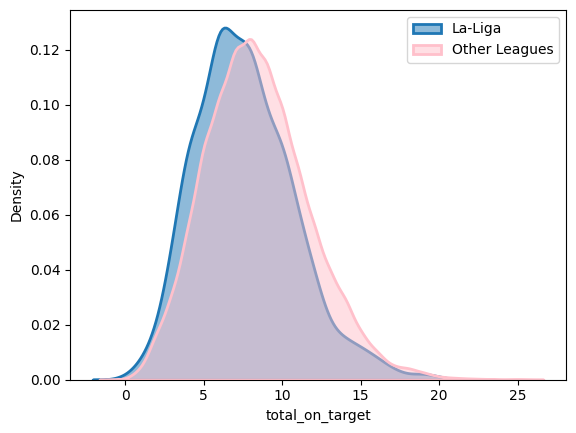

count       1897.0
mean     33.478387
std      11.409063
min            0.0
25%           25.5
50%           33.0
75%           41.0
max           78.0
Name: percentage_on_target, dtype: Float64



count       7633.0
mean     33.864994
std      11.014574
min            0.0
25%           26.5
50%           33.5
75%           40.5
max           80.0
Name: percentage_on_target, dtype: Float64


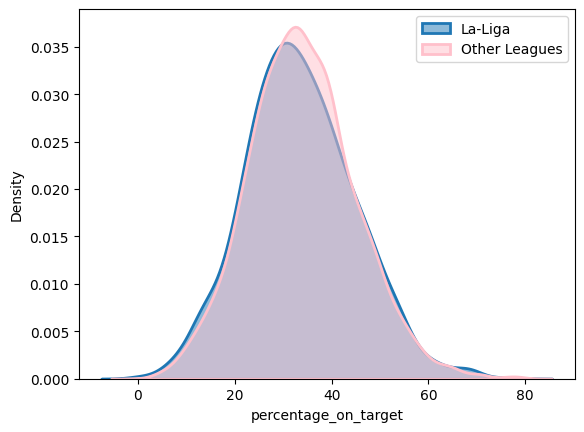

count       1897.0
mean     23.007907
std       6.332093
min            7.0
25%           19.0
50%           23.0
75%           27.0
max           50.0
Name: total_shots, dtype: Float64



count      7633.0
mean     25.12446
std      6.885022
min           5.0
25%          20.0
50%          25.0
75%          29.0
max          62.0
Name: total_shots, dtype: Float64


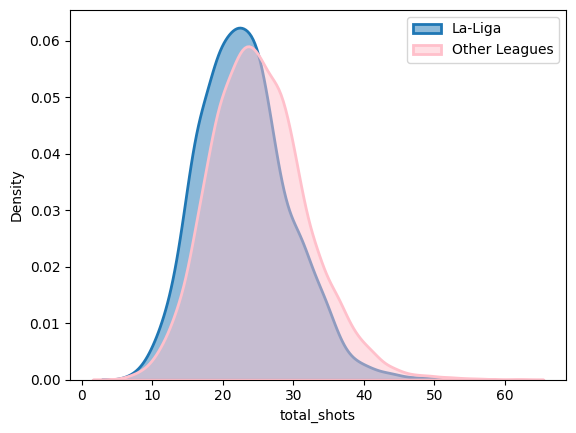

In [28]:
# Compare total shots, total on target, and mean percentage.
temp1["total_shots"] = temp1["t1_shots_taken"] + temp1["t2_shots_taken"]
temp1["total_on_target"] = temp1["t1_shots_on_target"] + temp1["t2_shots_on_target"]
temp1["percentage_on_target"] = (temp1["t1_shots_on_target_percentage"] + temp1["t2_shots_on_target_percentage"]) / 2

temp2["total_shots"] = temp2["t1_shots_taken"] + temp2["t2_shots_taken"]
temp2["total_on_target"] = temp2["t1_shots_on_target"] + temp2["t2_shots_on_target"]
temp2["percentage_on_target"] = (temp2["t1_shots_on_target_percentage"] + temp2["t2_shots_on_target_percentage"]) / 2


compare_columns({"La-Liga": temp1}, {"Other Leagues": temp2}, "total_on_target")
compare_columns({"La-Liga": temp1}, {"Other Leagues": temp2}, "percentage_on_target")
compare_columns({"La-Liga": temp1}, {"Other Leagues": temp2}, "total_shots")

In [29]:
# Check if formation affects the number of goals scored

laliga_df.dropna(subset=["Score"], inplace=True)
laliga_df["home_goals"] = laliga_df["Score"].str[0]
laliga_df["away_goals"] = laliga_df["Score"].str[-1]
laliga_df = laliga_df.astype({"home_goals": "int32", "away_goals": "int32"})

rest_df.dropna(subset=["Score"], inplace=True)
rest_df["home_goals"] = rest_df["Score"].str[0]
rest_df["away_goals"] = rest_df["Score"].str[-1]
rest_df = rest_df.astype({"home_goals": "int32", "away_goals": "int32"})

In [30]:
temph1 = laliga_df.groupby("t1_formation").agg({"home_goals": "sum", "t1_formation": "size"})
temph1.index.name = "formation"
temph1["laliga_home_goals"] = temph1["home_goals"] / temph1["t1_formation"]
temph1 = temph1.sort_values(by="t1_formation", ascending=False).iloc[:5, ].drop(["home_goals", "t1_formation"], axis=1)

temph2 = rest_df.groupby("t1_formation").agg({"home_goals": "sum", "t1_formation": "size"})
temph2.index.name = "formation"
temph2["rest_home_goals"] = temph2["home_goals"] / temph2["t1_formation"]
temph2 = temph2.sort_values(by="t1_formation", ascending=False).iloc[:5, ].drop(["home_goals", "t1_formation"], axis=1)

display(temph1, temph2)

,laliga_home_goals
formation,
(4-4-2),1.346290
(4-2-3-1),1.401914
(4-3-3),1.710227
(4-1-4-1),1.389831
(5-3-2),1.362745


,rest_home_goals
formation,
(4-2-3-1),1.679058
(4-3-3),1.718802
(3-4-3),1.553229
(3-5-2),1.457847
(4-4-2),1.418502


In [31]:
temp1 = pd.concat([temph1, temph2], axis=1).fillna(0)

temp1

,laliga_home_goals,rest_home_goals
formation,,
(4-4-2),1.346290,1.418502
(4-2-3-1),1.401914,1.679058
(4-3-3),1.710227,1.718802
(4-1-4-1),1.389831,0.000000
(5-3-2),1.362745,0.000000
(3-4-3),0.000000,1.553229
(3-5-2),0.000000,1.457847


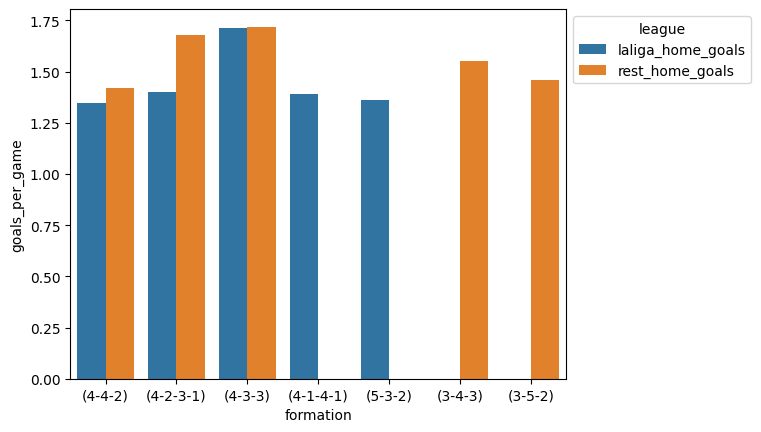

In [41]:
# Create a bar plot
p = pd.melt(temp1, value_vars=["laliga_home_goals", "rest_home_goals"], var_name="league", value_name="goals_per_game", ignore_index=False)

s = sns.barplot(p, x="formation", y="goals_per_game", hue="league")
sns.move_legend(s, "upper left", bbox_to_anchor=(1, 1))
plt.show()

In [42]:
tempa1 = laliga_df.groupby("t2_formation").agg({"away_goals": "sum", "t2_formation": "size"})
tempa1.index.name = "formation"
tempa1["laliga_away_goals"] = tempa1["away_goals"] / tempa1["t2_formation"] 

tempa1 = tempa1.sort_values(by="t2_formation", ascending=False).iloc[:5, ].drop(["away_goals", "t2_formation"], axis=1)


tempa2 = rest_df.groupby("t2_formation").agg({"away_goals": "sum", "t2_formation": "size"})
tempa2.index.name = "formation"
tempa2["rest_away_goals"] = tempa2["away_goals"] / tempa2["t2_formation"] 

tempa2 = tempa2.sort_values(by="t2_formation", ascending=False).iloc[:5, ].drop(["away_goals", "t2_formation"], axis=1)

display(tempa1, tempa2)

,laliga_away_goals
formation,
(4-4-2),0.986355
(4-2-3-1),1.035129
(4-3-3),1.400000
(5-3-2),1.007407
(4-1-4-1),1.201493


,rest_away_goals
formation,
(4-2-3-1),1.399890
(3-4-3),1.301439
(4-3-3),1.427481
(3-5-2),1.233668
(4-4-2),1.275974


In [35]:
temp2 = pd.concat([tempa1, tempa2], axis=1).fillna(0)

temp2

,laliga_away_goals,rest_away_goals
formation,,
(4-4-2),0.986355,1.275974
(4-2-3-1),1.035129,1.399890
(4-3-3),1.400000,1.427481
(5-3-2),1.007407,0.000000
(4-1-4-1),1.201493,0.000000
(3-4-3),0.000000,1.301439
(3-5-2),0.000000,1.233668


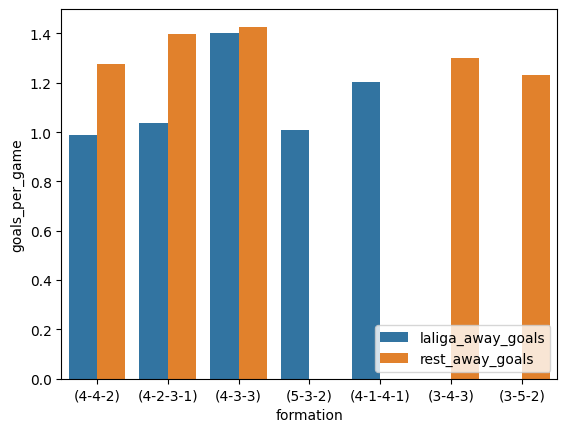

In [39]:
# Create a bar plot
p = pd.melt(temp2, value_vars=["laliga_away_goals", "rest_away_goals"], var_name="league", value_name="goals_per_game", ignore_index=False)

sns.barplot(p, x="formation", y="goals_per_game", hue="league")
plt.legend(loc="lower right")
plt.show()

,laliga_home_goals,laliga_away_goals,0
formation,,,
(4-4-2),1.346290,0.986355,-0.359935
(4-2-3-1),1.401914,1.035129,-0.366785
(4-3-3),1.710227,1.400000,-0.310227
(4-1-4-1),1.389831,1.201493,-0.188338
(5-3-2),1.362745,1.007407,-0.355338


,rest_home_goals,rest_away_goals,0
formation,,,
(4-2-3-1),1.679058,1.399890,-0.279167
(4-3-3),1.718802,1.427481,-0.291321
(3-4-3),1.553229,1.301439,-0.251789
(3-5-2),1.457847,1.233668,-0.224179
(4-4-2),1.418502,1.275974,-0.142528


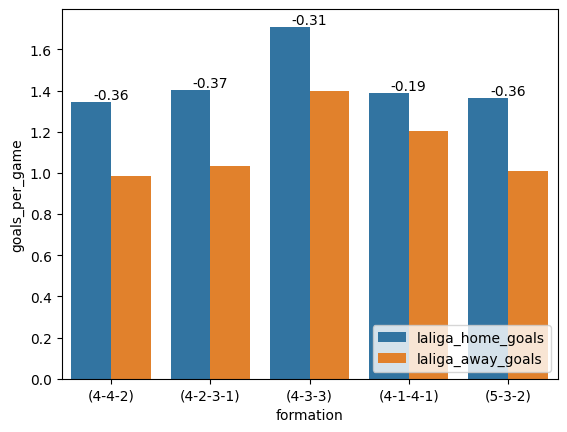

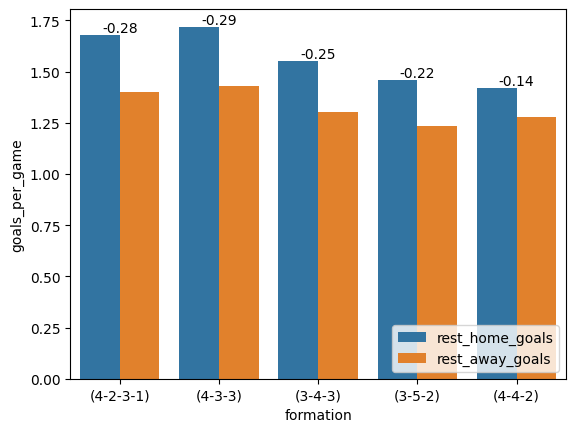

In [38]:
# Check the diff between home and away goals per game
templ = pd.concat([temph1, tempa1, tempa1.iloc[:, 0] - temph1.iloc[:, 0]], axis=1)
tempr = pd.concat([temph2, tempa2, tempa2.iloc[:, 0] - temph2.iloc[:, 0]], axis=1)

display(templ) # laliga diff between home and away (with % decrease)
display(tempr) # rest diff between home and away (with % decrease)

p = pd.melt(pd.concat([temph1, tempa1], axis=1), value_vars=["laliga_home_goals", "laliga_away_goals"], var_name="turf", value_name="goals_per_game", ignore_index=False)

s = sns.barplot(p, x="formation", y="goals_per_game", hue="turf")

diff = [0 for i in range(10)]
for index, i in enumerate(templ.iterrows()):
    diff[index] = round(i[1][0], 2)
    diff[index + 5] = round(i[1][0], 2)

for i, bar in enumerate(s.patches[:5]):
    # Get the height of the bar
    height = bar.get_height()
    # Place the text at the top of the bar (x, y position)
    s.text(bar.get_x() + bar.get_width(), height, 
            f'{diff[i]}',  # Format the label (use height directly if float)
            ha='center', va='bottom')
plt.legend(loc="lower right")
plt.show() # La Liga plot

p = pd.melt(pd.concat([temph2, tempa2], axis=1), value_vars=["rest_home_goals", "rest_away_goals"], var_name="turf", value_name="goals_per_game", ignore_index=False)

s = sns.barplot(p, x="formation", y="goals_per_game", hue="turf")

diff = [0 for i in range(10)]
for index, i in enumerate(tempr.iterrows()):
    diff[index] = round(i[1][0], 2)
    diff[index + 5] = round(i[1][0], 2)

for i, bar in enumerate(s.patches[:5]):
    # Get the height of the bar
    height = bar.get_height()
    # Place the text at the top of the bar (x, y position)
    s.text(bar.get_x() + bar.get_width(), height, 
            f'{diff[i]}',  # Format the label (use height directly if float)
            ha='center', va='bottom')
plt.legend(loc = "lower right")
plt.show() # Rest plot